In [1]:
import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [2]:
eq = Equilibrium.load("precise_QH_output.h5")[-1]

num_eta = 20
Ekin_frac = 3e-4
num_pitch = 2

s_min = 0.35
s_max = 0.45
pp = -1
qq = 8
data = np.load("poincare_data_Bcrit_0.91.npz")

pitch_invs = np.linspace(1/data['lam'][()],1.09,num_pitch)

# s_prof = np.linspace(s_min, s_max, 15)
# rhos = np.sqrt(s_prof)

rhos = np.linspace(s_min**0.5,s_max**0.5,10)


obj = TrappedResonance(
    eq, 
    rho=rhos, 
    num_eta=num_eta, 
    M=1, 
    N=1,
    n_max=8,
    DEBUG=True,
    wd_blur=1.2,
    pitch_invs=pitch_invs,
    pitch_method=2, 
    num_pitch=num_pitch,
    num_well=1, 
    num_transit=8,
    knots_per_transit=100, 
    num_quad=48, 
    KE_frac=np.array([Ekin_frac]),
    STAB_SACRIFICE=False, # True = sacrifice Omega_eta' for numerical stability,
    bt_filter_flag=False,
    rt_filter_flag=False,
    CONSERVATIVE_IW=False, # which island width function, True = conservative version

)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [3]:
res_arr = val['res_arr']
# print(res_arr)
i_res = 16
print(res_arr[i_res])

-0.125


In [4]:
np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s_4'][0,0,:])
Delta_s_4 = val['Delta_s_4'][:,0,0,i_res]
# s_res = val['s_res'][valid]
# p_arr = val['p_arr'][valid]
q_arr = val['q_arr']
Omega = val['omega_arr'][:,0,0]
# res_weight = val['res_weight'][:,0,0]

<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_2001130/788192736.py:9: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')


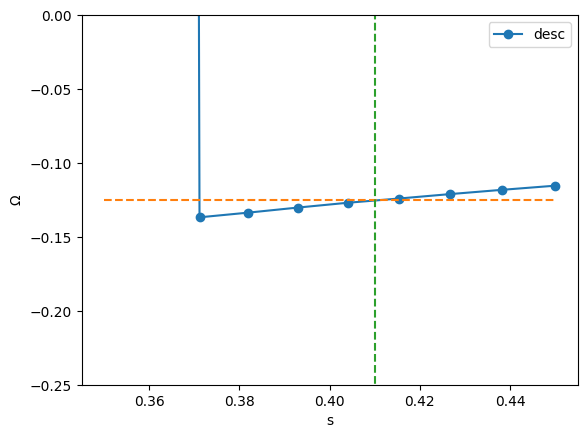

In [5]:
cross = 0.41

plt.figure()
# plt.plot(s_firm3d,Omega_firm3d,'-',label='firm3d')
plt.plot(rhos**2,Omega,'-o',label='desc')
plt.plot([rhos[0]**2,rhos[-1]**2],[res_arr[i_res],res_arr[i_res]],'--')
plt.plot([cross,cross],[-0.8,0.8],'--')
plt.xlabel('s')
plt.ylabel('$\Omega$')
plt.ylim([-0.25,0])
# plt.xlim(s_min,s_max)
plt.legend()
plt.show()



## Resonance is shifted by 0.0065 from firm3d location

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2001130/3766445976.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$')


[0.         0.         0.00590298 0.0110885  0.0110711  0.00924954
 0.01199289 0.01161271 0.01237002 0.01335402]


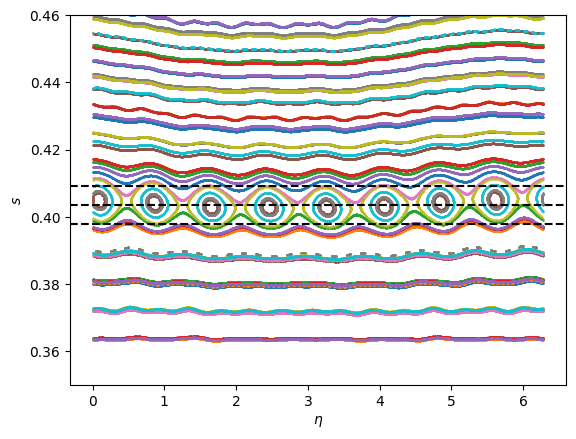

In [9]:
s_poinc = data['s_all']
etas_poinc = np.mod(data['etas_all'], 2*np.pi)

sshift = - 0.0065
# sshift=0

Delta_s = 4 * (Delta_s_4) ** (1/4)
print(Delta_s)

cross = 0.41 + sshift

plt.figure()
for i in range(len(s_poinc)):
    plt.scatter(etas_poinc[i],s_poinc[i],s=0.1)
plt.ylim(s_min,s_max+0.01)
plt.axhline([cross], color='k', linestyle='--')
plt.axhline([cross+Delta_s[4]/2], color='k', linestyle='--')
plt.axhline([cross-Delta_s[4]/2], color='k', linestyle='--')
plt.xlabel('$\eta$')
plt.ylabel('$s$')
plt.show()